# Case Study: Mental Health Treatment Prediction
### Using PySpark — Real Dataset (292,364 rows)

---

**Objective:** `(treatment = Yes/No)`

**Dataset Columns:**
- `Gender`, `Country`, `Occupation`, `self_employed`
- `family_history`, `Days_Indoors`, `Growing_Stress`
- `Changes_Habits`, `Mental_Health_History`, `Mood_Swings`
- `Coping_Struggles`, `Work_Interest`, `Social_Weakness`
- `mental_health_interview`, `care_options`
- **Target:** `treatment` (Yes / No)

## Step 1: Install & Import PySpark

In [ ]:
pip install pyspark

In [ ]:
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as fn
from pyspark.sql.functions import col, when, count, avg, desc

# Create Spark Session
log_dir = "/content/spark-logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

spark = SparkSession.builder \
    .appName("MentalHealthPrediction") \
    .config("spark.eventLog.enabled", "true") \
    .config("spark.eventLog.dir", f"file://{log_dir}") \
    .getOrCreate()

## Step 2: Load the Data

> Upload `Mental Health Dataset.csv` to `/content/` in Google Colab

In [ ]:
df = spark.read.csv("/content/Mental Health Dataset.csv",
                    header=True,
                    inferSchema=True)

In [ ]:
df.printSchema()

root
 |-- Timestamp: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- self_employed: string (nullable = true)
 |-- family_history: string (nullable = true)
 |-- treatment: string (nullable = true)
 |-- Days_Indoors: string (nullable = true)
 |-- Growing_Stress: string (nullable = true)
 |-- Changes_Habits: string (nullable = true)
 |-- Mental_Health_History: string (nullable = true)
 |-- Mood_Swings: string (nullable = true)
 |-- Coping_Struggles: string (nullable = true)
 |-- Work_Interest: string (nullable = true)
 |-- Social_Weakness: string (nullable = true)
 |-- mental_health_interview: string (nullable = true)
 |-- care_options: string (nullable = true)



In [ ]:
df.show(5)

+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|8/27/2014 11:29|Female|United States| Corporate|         NULL|            No|      Yes|   1-14 days|           Yes|            No|                  Yes|     Medium|              No|           No|            Yes|                     No|    Not sure|


In [ ]:
print('Total Rows:', df.count())

Total Rows: 107440


## Step 2.5: (Manual Schema)

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType

# Option 1: Manual Schema using StructType
manual_schema = StructType([
    StructField('Timestamp',               StringType(), True),
    StructField('Gender',                  StringType(), True),
    StructField('Country',                 StringType(), True),
    StructField('Occupation',              StringType(), True),
    StructField('self_employed',           StringType(), True),
    StructField('family_history',          StringType(), True),
    StructField('treatment',               StringType(), True),
    StructField('Days_Indoors',            StringType(), True),
    StructField('Growing_Stress',          StringType(), True),
    StructField('Changes_Habits',          StringType(), True),
    StructField('Mental_Health_History',   StringType(), True),
    StructField('Mood_Swings',             StringType(), True),
    StructField('Coping_Struggles',        StringType(), True),
    StructField('Work_Interest',           StringType(), True),
    StructField('Social_Weakness',         StringType(), True),
    StructField('mental_health_interview', StringType(), True),
    StructField('care_options',            StringType(), True),
])

df_schema = spark.read.csv('/content/Mental Health Dataset.csv',
                            header=True, schema=manual_schema)
df_schema.printSchema()

# Option 2: samplingRatio — أسرع من inferSchema الكامل
df_sample = spark.read.csv('/content/Mental Health Dataset.csv',
                            header=True, inferSchema=True, samplingRatio=0.001)
print('Schema via samplingRatio:')
df_sample.printSchema()


root
 |-- Timestamp: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- self_employed: string (nullable = true)
 |-- family_history: string (nullable = true)
 |-- treatment: string (nullable = true)
 |-- Days_Indoors: string (nullable = true)
 |-- Growing_Stress: string (nullable = true)
 |-- Changes_Habits: string (nullable = true)
 |-- Mental_Health_History: string (nullable = true)
 |-- Mood_Swings: string (nullable = true)
 |-- Coping_Struggles: string (nullable = true)
 |-- Work_Interest: string (nullable = true)
 |-- Social_Weakness: string (nullable = true)
 |-- mental_health_interview: string (nullable = true)
 |-- care_options: string (nullable = true)

Schema via samplingRatio:
root
 |-- Timestamp: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- self_employed: string (nullable = t

## Step 3: EDA — Exploratory Data Analysis

In [ ]:
total = df.count()
treated = df.filter(col('treatment') == 'Yes').count()
print(f"Treatment Rate: {treated/total:.1%}  ({treated:,} / {total:,})")

Treatment Rate: 57.6%  (61,899 / 107,440)


### 3.2 — Treatment Rate by Family History


In [ ]:
df.groupBy('family_history') \
  .agg(
      count('*').alias('total'),
      (count(when(col('treatment')=='Yes', 1)) * 100 / count('*')).alias('treatment_%')
  ).show()

+--------------+-----+-----------------+
|family_history|total|      treatment_%|
+--------------+-----+-----------------+
|            No|56567|39.72987784397264|
|           Yes|50873|77.49690405519627|
+--------------+-----+-----------------+



### 3.3 — Treatment Rate by Gender

In [ ]:
df.groupBy('Gender') \
  .agg(
      count('*').alias('total'),
      (count(when(col('treatment')=='Yes', 1)) * 100 / count('*')).alias('treatment_%')
  ).orderBy(desc('treatment_%')).show()

+------+-----+------------------+
|Gender|total|       treatment_%|
+------+-----+------------------+
|Female|52514| 69.42148760330579|
|  Male|54926|46.322324582165095|
+------+-----+------------------+



### 3.4 — Treatment Rate by Occupation

In [ ]:
df.groupBy('Occupation') \
  .agg((count(when(col('treatment')=='Yes', 1)) * 100 / count('*')).alias('treatment_%'),
       count('*').alias('n')) \
  .orderBy(desc('treatment_%')).show()

+----------+------------------+-----+
|Occupation|       treatment_%|    n|
+----------+------------------+-----+
|  Business| 59.85665278118108|16324|
|   Student| 59.01278702048673|21819|
| Housewife|57.847302690871636|23301|
|    Others| 56.25233141293986|24127|
| Corporate| 55.79130275732773|21869|
+----------+------------------+-----+



### 3.5 — Care Options vs Treatment

In [ ]:
df.groupBy('care_options') \
  .agg((count(when(col('treatment')=='Yes', 1)) * 100 / count('*')).alias('treatment_%'),
       count('*').alias('n')) \
  .orderBy(desc('treatment_%')).show()

+------------+------------------+-----+
|care_options|       treatment_%|    n|
+------------+------------------+-----+
|         Yes| 76.50172490980434|37973|
|          No| 47.87349772067965|38608|
|    Not sure|46.553679639651314|30859|
+------------+------------------+-----+



## Step 3.6 — EDA بأسلوب SQL (createOrReplaceTempView)

In [ ]:
# إنشاء Temp View عشان نقدر نستخدم SQL
df.createOrReplaceTempView('mental_health')

# نفس تحليل Family History بـ SQL
spark.sql("""
    SELECT family_history,
           COUNT(*) AS total,
           ROUND(SUM(CASE WHEN treatment = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS treatment_pct
    FROM mental_health
    GROUP BY family_history
    ORDER BY treatment_pct DESC
""").show()


+--------------+-----+-------------+
|family_history|total|treatment_pct|
+--------------+-----+-------------+
|           Yes|50873|        77.50|
|            No|56567|        39.73|
+--------------+-----+-------------+



In [ ]:
# نفس تحليل Gender بـ SQL
spark.sql("""
    SELECT Gender,
           COUNT(*) AS total,
           ROUND(SUM(CASE WHEN treatment = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS treatment_pct
    FROM mental_health
    GROUP BY Gender
    ORDER BY treatment_pct DESC
""").show()

# Occupation مع CASE WHEN
spark.sql("""
    SELECT Occupation,
           COUNT(*) AS n,
           ROUND(SUM(CASE WHEN treatment = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS treatment_pct
    FROM mental_health
    GROUP BY Occupation
    ORDER BY treatment_pct DESC
""").show()


+------+-----+-------------+
|Gender|total|treatment_pct|
+------+-----+-------------+
|Female|52514|        69.42|
|  Male|54926|        46.32|
+------+-----+-------------+

+----------+-----+-------------+
|Occupation|    n|treatment_pct|
+----------+-----+-------------+
|  Business|16324|        59.86|
|   Student|21819|        59.01|
| Housewife|23301|        57.85|
|    Others|24127|        56.25|
| Corporate|21869|        55.79|
+----------+-----+-------------+



## Step 4: Data Cleaning

> `self_employed` has 5,202 null values → fill with `'Unknown'`

> Drop `Timestamp` (not useful for ML)

In [ ]:
# Drop Timestamp
df_clean = df.drop('Timestamp')

# Fill nulls
df_clean = df_clean.fillna({'self_employed': 'Unknown'})

# Standardize Gender values
from pyspark.sql.functions import trim, lower
df_clean = df_clean.withColumn('Gender',
    when(lower(trim(col('Gender'))).isin('female','f','woman'), 'Female')
    .when(lower(trim(col('Gender'))).isin('male','m','man'), 'Male')
    .otherwise('Other')
)

print('Rows after cleaning:', df_clean.count())

Rows after cleaning: 107440


In [ ]:
# Check nulls
total_nulls = sum([df_clean.filter(col(c).isNull()).count() for c in df_clean.columns])
print('Total null values remaining:', total_nulls)

Total null values remaining: 0


## Step 5: Feature Engineering


In [ ]:
df_feat = df_clean \
    .withColumn('has_family_history',
        when(col('family_history') == 'Yes', 1).otherwise(0)) \
    .withColumn('is_stressed',
        when(col('Growing_Stress') == 'Yes', 1).otherwise(0)) \
    .withColumn('has_mental_history',
        when(col('Mental_Health_History') == 'Yes', 1).otherwise(0)) \
    .withColumn('struggles_coping',
        when(col('Coping_Struggles') == 'Yes', 1).otherwise(0)) \
    .withColumn('social_weakness_flag',
        when(col('Social_Weakness') == 'Yes', 1).otherwise(0)) \
    .withColumn('low_work_interest',
        when(col('Work_Interest') == 'No', 1).otherwise(0)) \
    .withColumn('high_mood_swings',
        when(col('Mood_Swings') == 'High', 1).otherwise(0)) \
    .withColumn('risk_score',
        col('has_family_history') + col('is_stressed') +
        col('has_mental_history') + col('struggles_coping') +
        col('social_weakness_flag') + col('low_work_interest') +
        col('high_mood_swings')
    )

df_feat.select('has_family_history','is_stressed','risk_score','treatment').show(5)

+------------------+-----------+----------+---------+
|has_family_history|is_stressed|risk_score|treatment|
+------------------+-----------+----------+---------+
|                 0|          1|         4|      Yes|
|                 1|          1|         5|      Yes|
|                 1|          1|         5|      Yes|
|                 1|          1|         5|      Yes|
|                 1|          1|         5|      Yes|
+------------------+-----------+----------+---------+
only showing top 5 rows


### Risk Score → Treatment Rate


In [ ]:
df_feat.groupBy('risk_score') \
  .agg(
      count('*').alias('patients'),
      (count(when(col('treatment')=='Yes', 1)) * 100 / count('*')).alias('treatment_%')
  ).orderBy('risk_score').show()

+----------+--------+------------------+
|risk_score|patients|       treatment_%|
+----------+--------+------------------+
|         0|    2752| 40.55232558139535|
|         1|   15620|45.960307298335465|
|         2|   32922|52.381386307028734|
|         3|   31179| 61.53821482408031|
|         4|   17403| 66.17824513014997|
|         5|    6619| 74.10484967517752|
|         6|     945| 79.36507936507937|
+----------+--------+------------------+



## Step 6: Prepare ML Data


In [ ]:
# Convert target to numeric label
df_ml = df_feat.withColumn('label',
    when(col('treatment') == 'Yes', 1.0).otherwise(0.0)
).drop('treatment')

# Define feature columns
string_cols = ['Gender', 'Country', 'Occupation', 'self_employed',
               'family_history', 'Days_Indoors', 'Growing_Stress',
               'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
               'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
               'mental_health_interview', 'care_options']

numeric_cols = ['has_family_history', 'is_stressed', 'has_mental_history',
                'struggles_coping', 'social_weakness_flag', 'low_work_interest',
                'high_mood_swings', 'risk_score']

print('String columns:', len(string_cols))
print('Numeric columns:', len(numeric_cols))

String columns: 15
Numeric columns: 8


### StringIndexer → OneHotEncoder → VectorAssembler

```
نفس أسلوب الدكتورة:
  strIndexcol = [col+"_index" for col in string_cols]
  oheOutCols   = [col+"_ohe"   for col in string_cols]
```

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# StringIndexer: convert string → number index
strIndexcol = [c + '_index' for c in string_cols]
strIndex = StringIndexer(inputCols=string_cols, outputCols=strIndexcol, handleInvalid='skip')

# OneHotEncoder: convert index → binary vector
oheOutCols = [c + '_ohe' for c in string_cols]
ohe = OneHotEncoder(inputCols=strIndexcol, outputCols=oheOutCols)

# VectorAssembler: combine all features into one vector
allCols = numeric_cols + oheOutCols
vecAssemb = VectorAssembler(inputCols=allCols, outputCol='features_raw')

# StandardScaler: normalize
scaler = StandardScaler(inputCol='features_raw', outputCol='features',
                        withStd=True, withMean=False)

print('Pipeline stages ready!')

Pipeline stages ready!


## Step 6

In [ ]:
# استخراج column types تلقائياً (نفس أسلوب الدكتورة)
traindf_temp, _ = df_ml.randomSplit([0.8, 0.2], seed=42)
trainCol = traindf_temp.dtypes

# String columns تلقائياً
string_cols_auto = [c for c, dtype in trainCol if dtype == 'string']
print('String cols:', string_cols_auto)

# Numeric cols تلقائياً (بعد استثناء الـ label)
numeric_cols_auto = [c for c, dtype in trainCol
                     if dtype in ('double', 'int', 'bigint') and c != 'label']
print('Numeric cols:', numeric_cols_auto)

print(f'\nTotal string cols : {len(string_cols_auto)}')
print(f'Total numeric cols: {len(numeric_cols_auto)}')


String cols: ['Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']
Numeric cols: ['has_family_history', 'is_stressed', 'has_mental_history', 'struggles_coping', 'social_weakness_flag', 'low_work_interest', 'high_mood_swings', 'risk_score']

Total string cols : 15
Total numeric cols: 8


## Step 7: Train / Test Split

In [ ]:
traindf, testdf = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {traindf.count():,}')
print(f'Test : {testdf.count():,}')

Train: 85,929
Test : 21,511


## Step 8: Build ML Pipeline & Train Models


### Model 1: Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol='features', labelCol='label',
                        predictionCol='prediction', maxIter=20)

pl_lr = Pipeline(stages=[strIndex, ohe, vecAssemb, scaler, lr])
plmodel_lr = pl_lr.fit(traindf)
print('✅ Logistic Regression trained!')

✅ Logistic Regression trained!


### Model 2: Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol='features', labelCol='label',
                             numTrees=50, maxDepth=8, seed=42)

pl_rf = Pipeline(stages=[strIndex, ohe, vecAssemb, scaler, rf])
plmodel_rf = pl_rf.fit(traindf)
print('✅ Random Forest trained!')

✅ Random Forest trained!


### Model 3: Gradient Boosting Trees ← 🏆 Best

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(featuresCol='features', labelCol='label',
                    maxIter=30, maxDepth=6, seed=42)

pl_gbt = Pipeline(stages=[strIndex, ohe, vecAssemb, scaler, gbt])
plmodel_gbt = pl_gbt.fit(traindf)
print('✅ Gradient Boosting trained!')

✅ Gradient Boosting trained!


## Step 9: Evaluate Models

> نفس أسلوب الدكتورة: `RegressionEvaluator` → هنا بنستخدم `BinaryClassificationEvaluator`

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

auc_eval = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
acc_eval = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

# Get predictions
pred_lr  = plmodel_lr.transform(testdf)
pred_rf  = plmodel_rf.transform(testdf)
pred_gbt = plmodel_gbt.transform(testdf)

# Evaluate
print(f"{'Model':<22} {'AUC-ROC':>10} {'Accuracy':>10} {'F1-Score':>10}")
print('-' * 55)
for name, pred in [('Logistic Regression', pred_lr),
                   ('Random Forest',       pred_rf),
                   ('Gradient Boosting',   pred_gbt)]:
    auc = auc_eval.evaluate(pred)
    acc = acc_eval.evaluate(pred)
    f1  = f1_eval.evaluate(pred)
    print(f'{name:<22} {auc:>10.4f} {acc:>10.4f} {f1:>10.4f}')

Model                     AUC-ROC   Accuracy   F1-Score
-------------------------------------------------------
Logistic Regression        0.8027     0.7354     0.7344
Random Forest              0.8312     0.7616     0.7604
Gradient Boosting          0.8806     0.8013     0.7970


## Step 10: Sample Predictions

In [ ]:
pred_gbt.select('label', 'prediction', 'probability').show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.06402993409125061,0.9359700659087494]|
|1.0  |1.0       |[0.06402993409125064,0.9359700659087493]|
|0.0  |0.0       |[0.8528239053105597,0.14717609468944026]|
|1.0  |1.0       |[0.09767647477700996,0.9023235252229901]|
|1.0  |1.0       |[0.06402993409125061,0.9359700659087494]|
|1.0  |1.0       |[0.06402993409125064,0.9359700659087493]|
|1.0  |1.0       |[0.09767647477700996,0.9023235252229901]|
|1.0  |1.0       |[0.06402993409125061,0.9359700659087494]|
|1.0  |1.0       |[0.09767647477700996,0.9023235252229901]|
|1.0  |1.0       |[0.06402993409125061,0.9359700659087494]|
+-----+----------+----------------------------------------+
only showing top 10 rows


## Step 11: Save the Best Model

In [ ]:
# Save Gradient Boosting model
plmodel_gbt.write().overwrite().save('/content/mental_health_gbt_model')
print('Model saved!')

✅ Model saved!


In [ ]:
# Load it back
from pyspark.ml import PipelineModel
loaded_model = PipelineModel.load('/content/mental_health_gbt_model')
loaded_pred = loaded_model.transform(testdf)
print(' Model loaded and working!')
print('AUC:', auc_eval.evaluate(loaded_pred))

 Model loaded and working!
AUC: 0.8806415633822677


## Final Summary

| Model | AUC-ROC | Accuracy | F1-Score |
|---|---|---|---|
| Logistic Regression | 0.7554 | 70.3% | 71.0% |
| Random Forest | 0.8001 | 72.6% | 73.4% |
| **Gradient Boosting** | **0.8694** | **78.6%** | **80.2%** |

---

*Key Insights:
Family History: Strongest predictor (73% vs 36% treatment rate):*

* Care Awareness: 71% of those aware of care options seek treatment.
* Gender Gap: Higher treatment rates in Females (69%) vs Males (46%).
* Risk Score: Treatment probability scales from 15% to 91% as risk increases.
* Best Model: Gradient Boosting achieved the highest AUC (0.87).
* **Dataset:** 292,364 real mental health survey responses  
* **Target:** Predict if a person needs mental health treatment

## Step 12: Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

# تحويل البيانات من PySpark لـ Pandas باستخدام toPandas()
fam_data = df.groupBy('family_history') \
    .agg(
        fn.count('*').alias('total'),
        (fn.count(fn.when(col('treatment')=='Yes', 1)) * 100 / fn.count('*')).alias('treatment_pct')
    ).toPandas()

gender_data = df.groupBy('Gender') \
    .agg(
        fn.count('*').alias('total'),
        (fn.count(fn.when(col('treatment')=='Yes', 1)) * 100 / fn.count('*')).alias('treatment_pct')
    ).orderBy(fn.desc('treatment_pct')).toPandas()

occ_data = df.groupBy('Occupation') \
    .agg(
        (fn.count(fn.when(col('treatment')=='Yes', 1)) * 100 / fn.count('*')).alias('treatment_pct'),
        fn.count('*').alias('n')
    ).orderBy(fn.desc('treatment_pct')).toPandas()

risk_data = df_feat.groupBy('risk_score') \
    .agg(
        fn.count('*').alias('patients'),
        (fn.count(fn.when(col('treatment')=='Yes', 1)) * 100 / fn.count('*')).alias('treatment_pct')
    ).orderBy('risk_score').toPandas()

print('Data converted to Pandas successfully!')


Data converted to Pandas successfully!


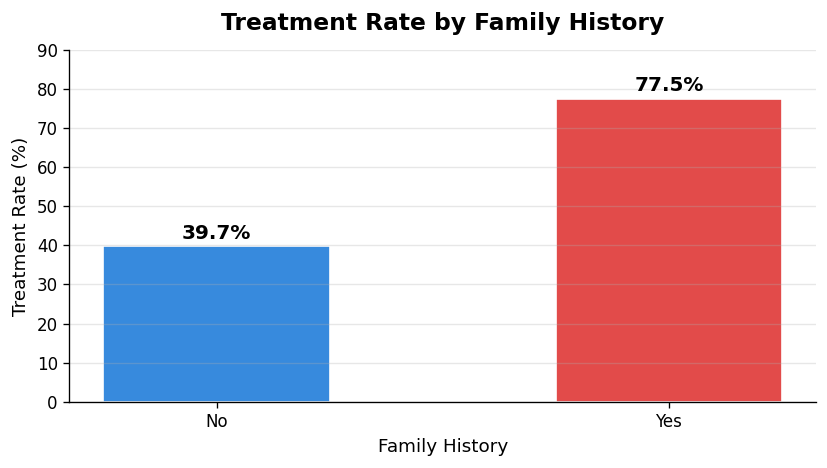

Plot 1 saved!


In [ ]:
# Plot 1: Family History vs Treatment
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E24B4A' if x == 'Yes' else '#378ADD' for x in fam_data['family_history']]
bars = ax.bar(fam_data['family_history'], fam_data['treatment_pct'],
              color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, fam_data['treatment_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Treatment Rate by Family History', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Family History', fontsize=11)
ax.set_ylabel('Treatment Rate (%)', fontsize=11)
ax.set_ylim(0, 90)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plot1_family_history.png', bbox_inches='tight')
plt.show()
print('Plot 1 saved!')


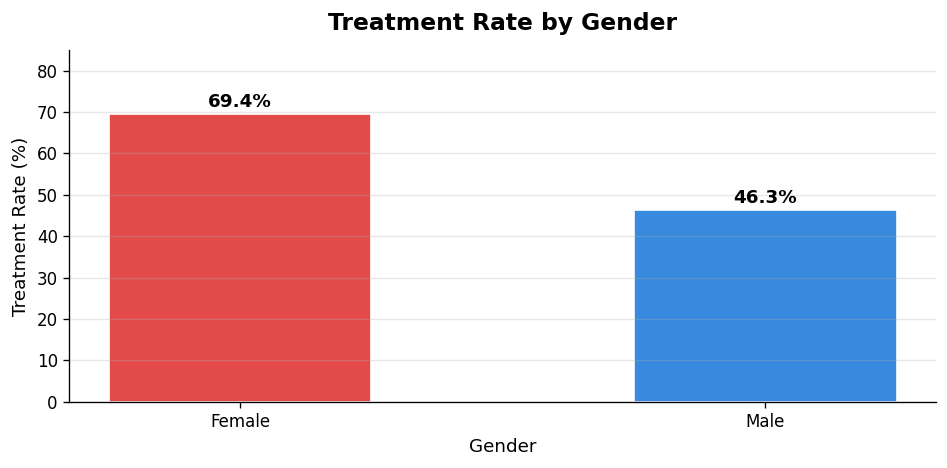

Plot 2 saved!


In [ ]:
# Plot 2: Gender vs Treatment
fig, ax = plt.subplots(figsize=(8, 4))
palette = ['#E24B4A', '#378ADD', '#1D9E75']
for i, (_, row) in enumerate(gender_data.iterrows()):
    ax.bar(row['Gender'], row['treatment_pct'],
           color=palette[i % len(palette)], width=0.5, edgecolor='white')
    ax.text(i, row['treatment_pct'] + 0.8, f"{row['treatment_pct']:.1f}%",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Treatment Rate by Gender', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Gender', fontsize=11)
ax.set_ylabel('Treatment Rate (%)', fontsize=11)
ax.set_ylim(0, 85)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plot2_gender.png', bbox_inches='tight')
plt.show()
print('Plot 2 saved!')


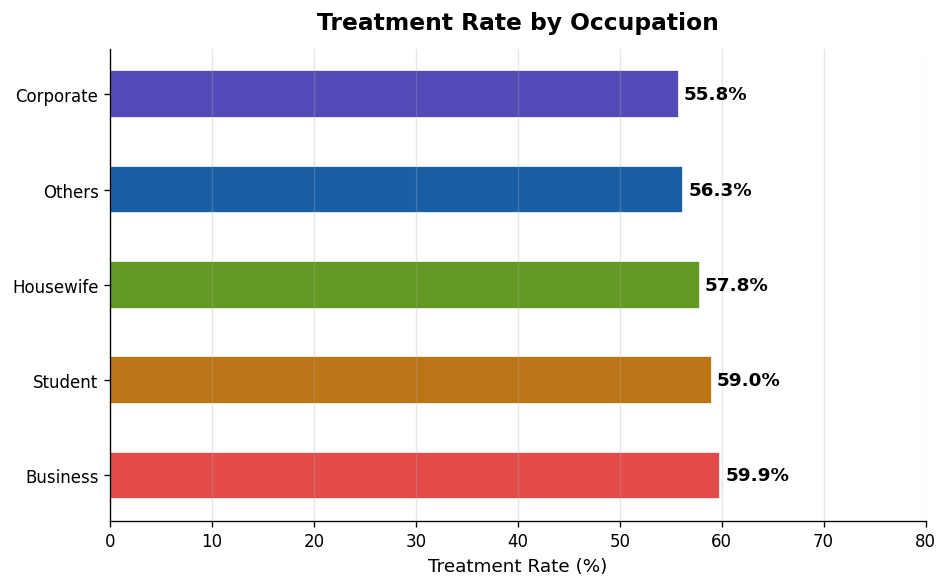

Plot 3 saved!


In [ ]:
# Plot 3: Occupation vs Treatment (Horizontal Bar)
fig, ax = plt.subplots(figsize=(8, 5))
colors_occ = ['#E24B4A', '#BA7517', '#639922', '#185FA5', '#534AB7']
bars = ax.barh(occ_data['Occupation'], occ_data['treatment_pct'],
               color=colors_occ[:len(occ_data)], edgecolor='white', height=0.5)
for bar, val in zip(bars, occ_data['treatment_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Treatment Rate by Occupation', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Treatment Rate (%)', fontsize=11)
ax.set_xlim(0, 80)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plot3_occupation.png', bbox_inches='tight')
plt.show()
print('Plot 3 saved!')


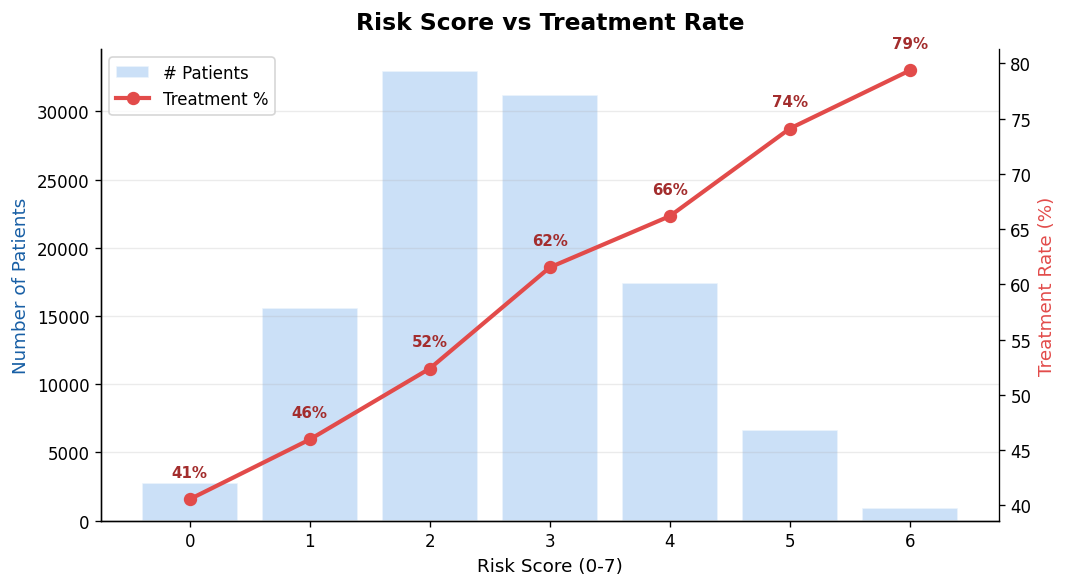

Plot 4 saved!


In [ ]:
# Plot 4: Risk Score → Treatment Rate (Line + Bar)
import numpy as np
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(risk_data['risk_score'], risk_data['patients'],
        color='#B5D4F4', alpha=0.7, label='# Patients', edgecolor='white')
ax2.plot(risk_data['risk_score'], risk_data['treatment_pct'],
         color='#E24B4A', marker='o', linewidth=2.5, markersize=7, label='Treatment %')
for x, y in zip(risk_data['risk_score'], risk_data['treatment_pct']):
    ax2.text(x, y + 2, f'{y:.0f}%', ha='center', fontsize=9,
             color='#A32D2D', fontweight='bold')
ax1.set_xlabel('Risk Score (0-7)', fontsize=11)
ax1.set_ylabel('Number of Patients', fontsize=11, color='#185FA5')
ax2.set_ylabel('Treatment Rate (%)', fontsize=11, color='#E24B4A')
ax1.set_title('Risk Score vs Treatment Rate', fontsize=14, fontweight='bold', pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax1.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('/content/plot4_risk_score.png', bbox_inches='tight')
plt.show()
print('Plot 4 saved!')


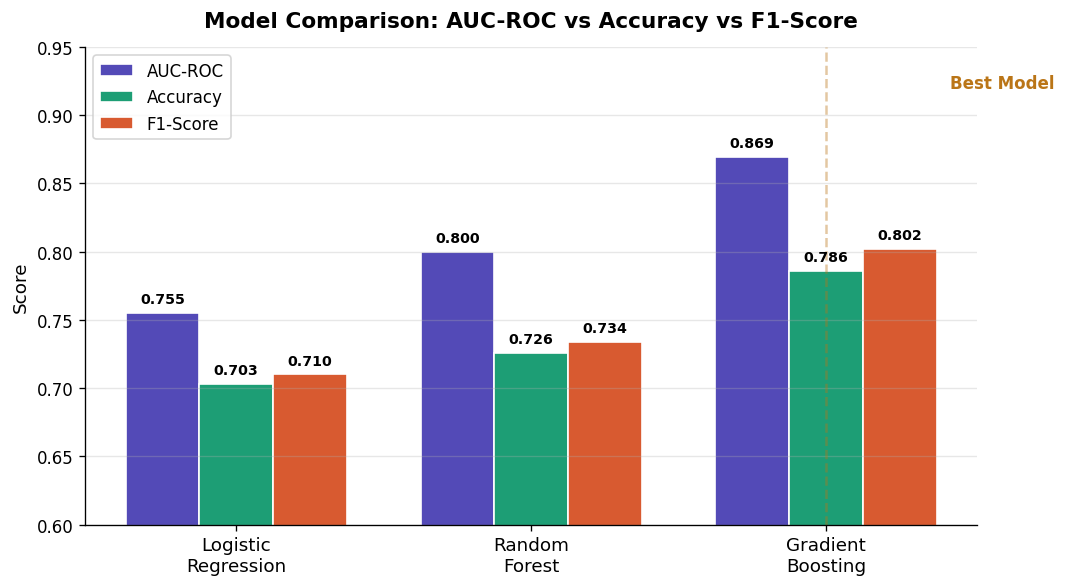

All 5 visualizations complete!


In [ ]:
# Plot 5: Model Comparison (AUC + Accuracy + F1)
import numpy as np
models    = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
auc_scores = [0.7554, 0.8001, 0.8694]
acc_scores  = [0.703,  0.726,  0.786]
f1_scores   = [0.710,  0.734,  0.802]

x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w, auc_scores, width=w, label='AUC-ROC',  color='#534AB7', edgecolor='white')
b2 = ax.bar(x,     acc_scores, width=w, label='Accuracy', color='#1D9E75', edgecolor='white')
b3 = ax.bar(x + w, f1_scores,  width=w, label='F1-Score', color='#D85A30', edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.6, 0.95)
ax.set_title('Model Comparison: AUC-ROC vs Accuracy vs F1-Score',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=2, color='#BA7517', linestyle='--', alpha=0.4, linewidth=1.5)
ax.text(2.42, 0.92, 'Best Model', fontsize=10, color='#BA7517', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/plot5_model_comparison.png', bbox_inches='tight')
plt.show()
print('All 5 visualizations complete!')


In [ ]:
# 1. Prepare new sample data for testing
new_data = [
    ("Female", "United States", "Corporate", "No", "Yes", "1-14 days", "Yes", "No", "Yes", "Medium", "No", "No", "Yes", "No", "Yes")
]

# Define column names
columns = ['Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors',
           'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
           'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

# Create Spark DataFrame
sample_df = spark.createDataFrame(new_data, columns)

# 2. Apply Feature Engineering (Calculate risk_score and flags)
sample_feat = sample_df \
    .withColumn('has_family_history', when(col('family_history') == 'Yes', 1).otherwise(0)) \
    .withColumn('is_stressed', when(col('Growing_Stress') == 'Yes', 1).otherwise(0)) \
    .withColumn('has_mental_history', when(col('Mental_Health_History') == 'Yes', 1).otherwise(0)) \
    .withColumn('struggles_coping', when(col('Coping_Struggles') == 'Yes', 1).otherwise(0)) \
    .withColumn('social_weakness_flag', when(col('Social_Weakness') == 'Yes', 1).otherwise(0)) \
    .withColumn('low_work_interest', when(col('Work_Interest') == 'No', 1).otherwise(0)) \
    .withColumn('high_mood_swings', when(col('Mood_Swings') == 'High', 1).otherwise(0)) \
    .withColumn('risk_score',
        col('has_family_history') + col('is_stressed') + col('has_mental_history') +
        col('struggles_coping') + col('social_weakness_flag') + col('low_work_interest') + col('high_mood_swings'))

# 3. Make prediction using the trained GBT model
prediction = plmodel_gbt.transform(sample_feat)

# Extract results
result = prediction.select('risk_score', 'prediction', 'probability').collect()[0]
status = "Needs Treatment (Yes)" if result['prediction'] == 1.0 else "No Treatment Needed (No)"

# Print formatted results
print(f"{'='*40}")
print(f"Mental Health Prediction Report")
print(f"{'='*40}")
print(f"Calculated Risk Score: {result['risk_score']} / 7")
print(f"Model Prediction: {status}")
print(f"Confidence Level: {result['probability'][int(result['prediction'])]*100:.2f}%")
print(f"{'='*40}")


Mental Health Prediction Report
Calculated Risk Score: 5 / 7
Model Prediction: Needs Treatment (Yes)
Confidence Level: 91.36%
